# Notebook 02: Feature Engineering

Builds on notebooks/01_EDA.ipynb findings. This notebook:
- Re-applies the locked preprocessing pipeline (noise-column drop, IQR clip, time features)
- Adds cyclical encoding, rolling statistics, lag features, and domain interaction features
- Runs a 4-stage feature selection pipeline (zero-signal -> correlation -> RF importance -> permutation importance)
- Saves the final engineered train/test sets to data/processed/ for notebook 03 onward

All functions are imported from src/ - no logic is redefined here.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.data_preprocessing import (
    load_data, drop_noise_columns, clip_outliers_iqr,
    extract_time_features, temporal_train_test_split,
    get_feature_columns, scale_data
)
from src.feature_engineering import (
    add_cyclical_features, add_rolling_features, add_lag_features,
    add_interaction_features, drop_engineering_nans,
    select_features_correlation, select_features_rf_importance,
    select_features_permutation, save_processed_data
)

pd.set_option("display.max_columns", None)

## 1. Reload and re-apply locked preprocessing

Re-running these steps here (rather than loading a saved intermediate file) keeps
this notebook self-contained and reproducible end-to-end, per the assessment's
"executable end-to-end" requirement.

In [2]:
df = load_data("../data/raw/energy_data_set.csv")
df = drop_noise_columns(df)  # drops rv1, rv2 - confirmed near-zero correlation in EDA
df, fences = clip_outliers_iqr(df, "Appliances")
df = extract_time_features(df)

print(f"Shape after preprocessing: {df.shape}")
print(f"Outlier fences: {fences}")

Shape after preprocessing: (19735, 32)
Outlier fences: {'Q1': 50.0, 'Q3': 100.0, 'IQR': 50.0, 'upper_fence': 175.0, 'lower_fence': 0, 'outliers_high': 2138, 'outliers_low': 0}


## 2. Cyclical encoding

hour (period=24) and day_of_week (period=7) are encoded as sin/cos pairs so the
model sees hour 23 and hour 0 as adjacent, matching the daily cycle confirmed
by STL decomposition and the ACF U-shape.

In [3]:
df = add_cyclical_features(df, "hour", 24)
df = add_cyclical_features(df, "day_of_week", 7)

df[["hour", "hour_sin", "hour_cos", "day_of_week", "day_of_week_sin", "day_of_week_cos"]].head()

,hour,hour_sin,hour_cos,day_of_week,day_of_week_sin,day_of_week_cos
0,17,-0.965926,-0.258819,0,0.0,1.0
1,17,-0.965926,-0.258819,0,0.0,1.0
2,17,-0.965926,-0.258819,0,0.0,1.0
3,17,-0.965926,-0.258819,0,0.0,1.0
4,17,-0.965926,-0.258819,0,0.0,1.0


## 3. Rolling statistics and lag features

Rolling stats (1hr/3hr/6hr = 6/18/36 steps) and lags (1, 3, 6, 18, 36, 144 steps)
are computed on Appliances, confirmed by the ACF/PACF analysis (PACF drops after
lag 1-2; lag 144 ACF ~0.35 captures the daily cycle; lag 36 retained for phase info
despite near-zero ACF).

Rolling stats are shifted by 1 step internally before the window is applied, so no
feature at time t ever includes the value being predicted at time t.

In [4]:
df = add_rolling_features(df, "Appliances", windows=[6, 18, 36])
df = add_lag_features(df, "Appliances", lags=[1, 3, 6, 18, 36, 144])

new_cols = [c for c in df.columns if "roll" in c or "lag" in c]
df[new_cols].head(10)

,Appliances_roll6_mean,Appliances_roll6_std,Appliances_roll18_mean,Appliances_roll18_std,Appliances_roll36_mean,Appliances_roll36_std,Appliances_lag1,Appliances_lag3,Appliances_lag6,Appliances_lag18,Appliances_lag36,Appliances_lag144
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,50.0,60.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,50.0,60.0,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,60.0,50.0,NaN,NaN,NaN,NaN
6,55.000000,5.477226,NaN,NaN,NaN,NaN,50.0,50.0,60.0,NaN,NaN,NaN
7,55.000000,5.477226,NaN,NaN,NaN,NaN,60.0,60.0,60.0,NaN,NaN,NaN
8,55.000000,5.477226,NaN,NaN,NaN,NaN,60.0,50.0,50.0,NaN,NaN,NaN
9,56.666667,5.163978,NaN,NaN,NaN,NaN,60.0,60.0,50.0,NaN,NaN,NaN


## 4. Interaction features

- heat_index_proxy: T_out x RH_out
- indoor_outdoor_delta: mean(T1..T9) - T_out
- weekend_lunch_peak: week_status AND hour in {11, 12} - encodes the EDA finding
  that weekends show an 11:00-12:00 peak weekdays do not

In [5]:
df = add_interaction_features(df)
df[["heat_index_proxy", "indoor_outdoor_delta", "weekend_lunch_peak"]].describe()

,heat_index_proxy,indoor_outdoor_delta,weekend_lunch_peak
count,19735.000000,19735.000000,19735.000000
mean,545.589078,11.970094,0.023106
std,355.853117,3.674681,0.150244
min,-455.700000,-1.058519,0.000000
25%,299.269444,9.597083,0.000000
50%,542.133333,12.132540,0.000000
75%,779.777778,14.492778,0.000000
max,1539.400000,21.468642,1.000000


## 5. Drop rows with engineering-induced NaNs

Lag-144 requires 144 prior rows, so the first 144 rows of the dataset cannot have
a complete feature set. These are dropped rather than imputed, since imputing a
lag or rolling feature would fabricate history that doesn't exist.

In [6]:
df, drop_info = drop_engineering_nans(df)
print(drop_info)
print(f"Shape after dropping: {df.shape}")

{'n_dropped': 144, 'pct_dropped': 0.7297}
Shape after dropping: (19591, 51)


## 6. Feature selection - Stage 2: correlation redundancy

Stage 1 (zero-signal removal of rv1/rv2) is already complete from preprocessing.
This stage removes pairs of features correlated above 0.95, keeping whichever
member of the pair correlates more strongly with Appliances.

In [7]:
print(df["week_status"].unique())
print(df["week_status"].dtype)
print(df["hour"].unique()[:5], df["hour"].dtype)

['Weekday' 'Weekend']
object
[17 18 19 20 21] int32


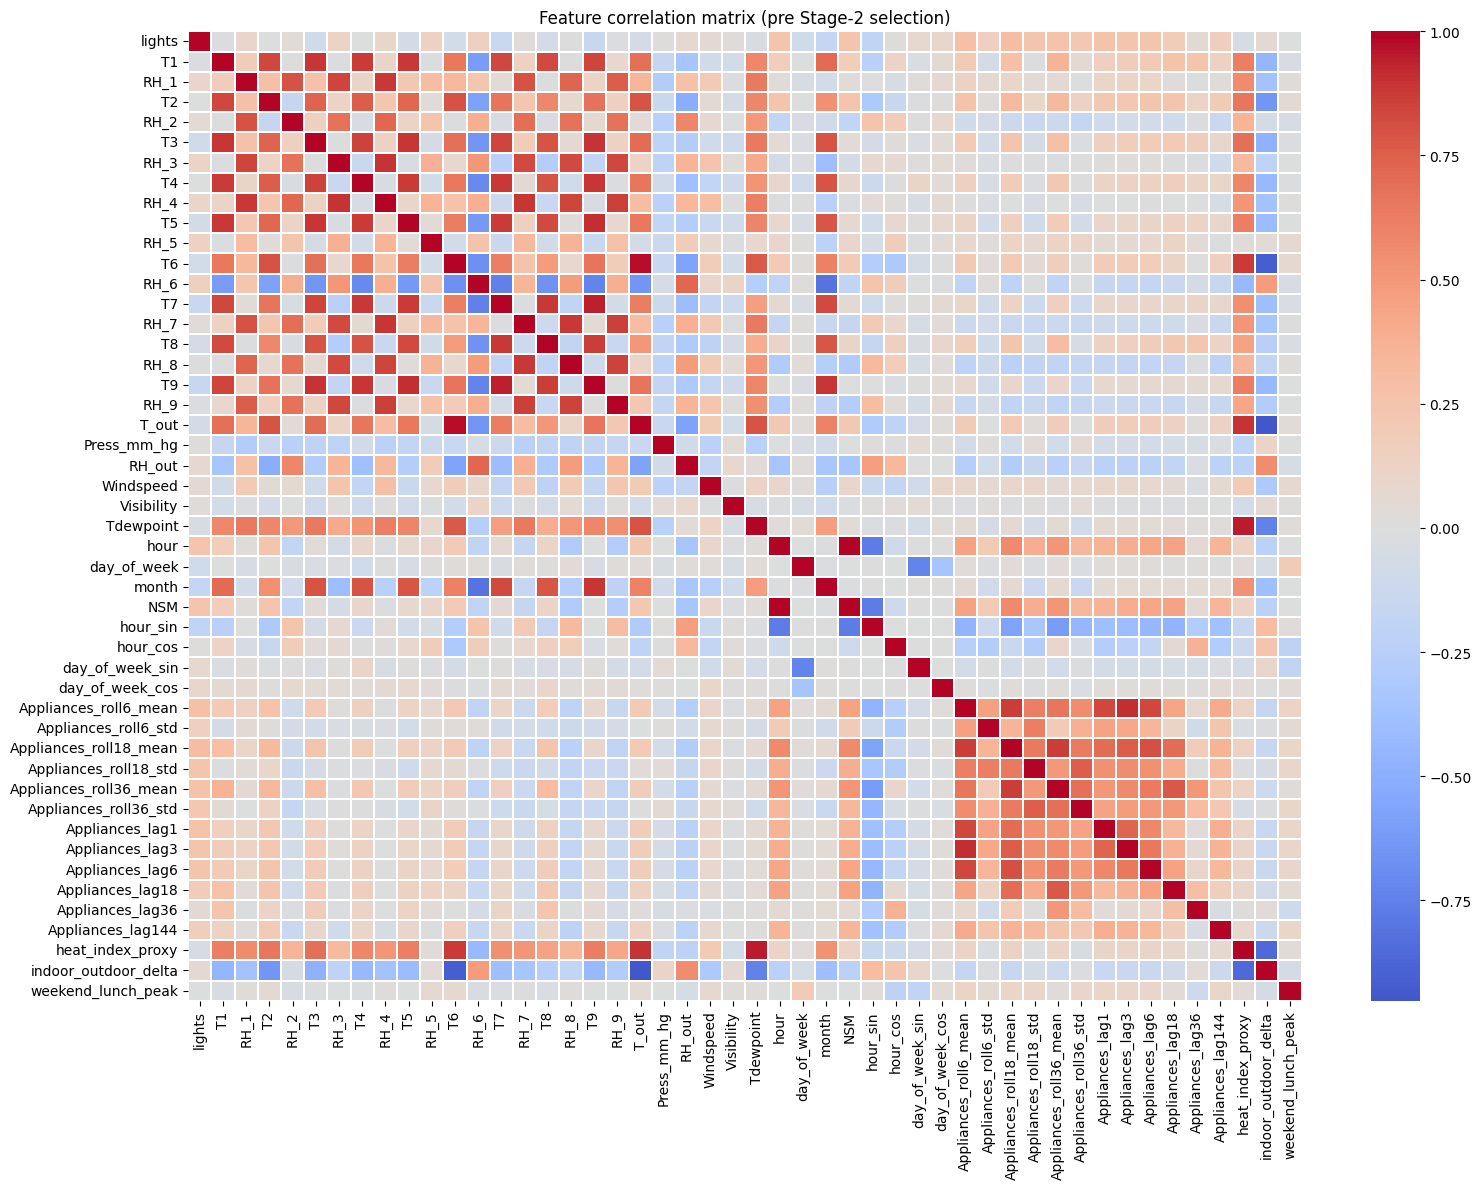

In [8]:
feature_cols = get_feature_columns(df)

plt.figure(figsize=(16, 12))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0, linewidths=0.1)
plt.title("Feature correlation matrix (pre Stage-2 selection)")
plt.tight_layout()
plt.savefig("../reports/figures/08_feature_correlation_heatmap.png", dpi=150)
plt.show()

T1-T9 and Tdewpoint form a dense correlated block (same building, same
timestamps). T6/RH_6 stand apart, confirming their outdoor-adjacent nature
from EDA. Appliances_roll*/lag* features are strongly self-correlated as
expected. Only two pairs crossed the 0.95 threshold: T_out/T6 (0.9748) and
NSM/hour (0.9992) - both near-duplicates, correctly dropped by Stage 2.

In [9]:
retained_stage2, dropped_pairs = select_features_correlation(
    df, feature_cols, target_col="Appliances", threshold=0.95
)

print(f"Retained: {len(retained_stage2)} of {len(feature_cols)}")
print(f"Dropped {len(dropped_pairs)} redundant features:")
for weaker, stronger, corr in dropped_pairs:
    print(f"  {weaker} (corr={corr}) redundant with {stronger}")

Retained: 46 of 48
Dropped 2 redundant features:
  T_out (corr=0.9748) redundant with T6
  NSM (corr=0.9992) redundant with hour


## 7. Temporal split and scaling

Split before Stage 3/4 selection so importance is measured on a train-fit scaler,
not leaked test statistics. 80/20 temporal split, no shuffling, scalers fit on
train only - consistent with the locked blueprint.

In [ ]:
train_df, test_df = temporal_train_test_split(df, test_size=0.2)
X_train, X_test, y_train, y_test, feature_scaler, target_scaler = scale_data(
    train_df, test_df, retained_stage2, target_col="Appliances"
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (15672, 46), Test: (3919, 46)


## 8. Feature selection - Stage 3: Random Forest importance

Impurity-based importance from a Random Forest gives a fast first pass at ranking
the Stage-2 survivors. This is a ranking tool, not a final cut - Stage 4 confirms
it with permutation importance to guard against RF's bias toward
high-cardinality/continuous features.

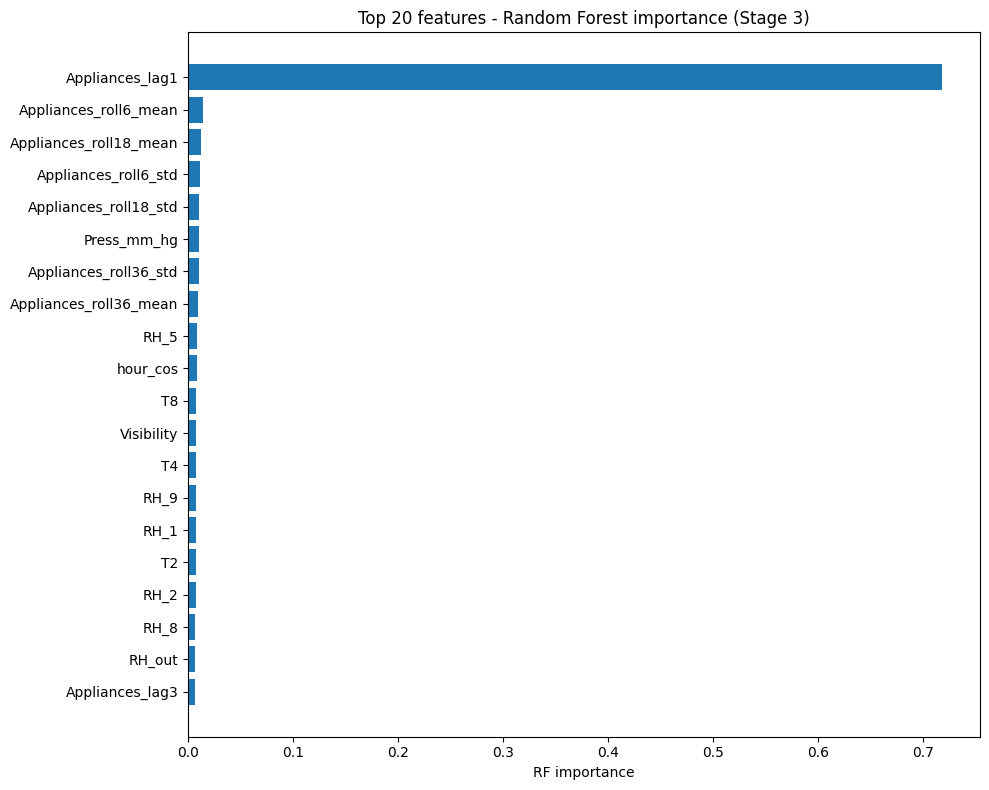

In [12]:
retained_stage3, importance_df = select_features_rf_importance(
    X_train, y_train,
    retained_stage2, top_n=None  # keep all, ranked, for now
)

plt.figure(figsize=(10, 8))
top20 = importance_df.head(20)
plt.barh(top20["feature"][::-1], top20["importance"][::-1])
plt.xlabel("RF importance")
plt.title("Top 20 features - Random Forest importance (Stage 3)")
plt.tight_layout()
plt.savefig("../reports/figures/09_rf_feature_importance.png", dpi=150)
plt.show()

Appliances_lag1 dominates (~0.72), consistent with the AR(1) structure seen
in PACF. Rolling stats (roll6/roll18/roll36) form a clear second tier,
followed by a long tail of raw sensors and lag3. Press_mm_hg ranking in the
top 8 is unexpected - flagging it to check against Stage 4 before trusting it.

## 9. Feature selection - Stage 4: permutation importance

Confirms Stage 3 by measuring actual performance drop when each feature is
shuffled on held-out data, using the same RF as the scoring model.

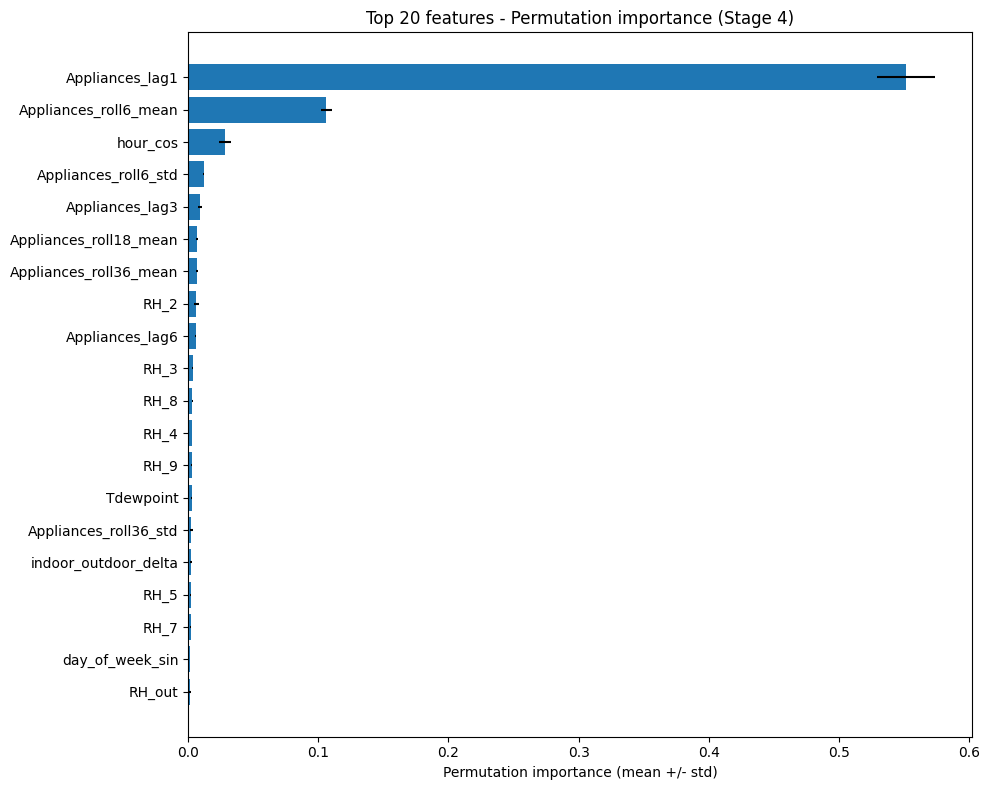

Stage 4 retained: 32 of 46


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

retained_stage4, perm_df = select_features_permutation(
    rf_final, X_test, y_test,
    retained_stage2, n_repeats=10, random_state=42
)

plt.figure(figsize=(10, 8))
top20_perm = perm_df.head(20)
plt.barh(top20_perm["feature"][::-1], top20_perm["importance_mean"][::-1],
         xerr=top20_perm["importance_std"][::-1])
plt.xlabel("Permutation importance (mean +/- std)")
plt.title("Top 20 features - Permutation importance (Stage 4)")
plt.tight_layout()
plt.savefig("../reports/figures/10_permutation_importance.png", dpi=150)
plt.show()

print(f"Stage 4 retained: {len(retained_stage4)} of {len(retained_stage2)}")

Confirms Appliances_lag1 (~0.55) and roll6_mean (~0.10) as the two clear
drivers, with a much larger gap than Stage 3 showed. hour_cos jumps to a
clear third (~0.03) - likely under-credited by RF due to shared signal
with correlated time/temp features. Press_mm_hg drops out of the top 20,
confirming its Stage 3 ranking was an impurity-bias artifact, not real
signal. Bottom features (day_of_week_sin, RH_out) sit near zero - likely
redundant with other retained features.

## 10. Final feature set and save

Final feature list = Stage 4 survivors. Saving:
- Full engineered train/test CSVs (all Stage-2 features, for flexibility in
  notebook 03+ if a model wants a fuller feature set)
- The final selected feature list as a text file
- Fitted scalers via joblib, for consistent inverse-transform at evaluation time

In [14]:
save_processed_data(train_df, "../data/processed/train_engineered.csv")
save_processed_data(test_df, "../data/processed/test_engineered.csv")

with open("../data/processed/selected_features.txt", "w") as f:
    f.write("\n".join(retained_stage4))

joblib.dump(feature_scaler, "../models/feature_scaler.pkl")
joblib.dump(target_scaler, "../models/target_scaler.pkl")

print(f"Saved {len(retained_stage4)} final features and scalers.")
print(retained_stage4)

Saved 32 final features and scalers.
['Appliances_lag1', 'Appliances_roll6_mean', 'hour_cos', 'Appliances_roll6_std', 'Appliances_lag3', 'Appliances_roll18_mean', 'Appliances_roll36_mean', 'RH_2', 'Appliances_lag6', 'RH_3', 'RH_8', 'RH_4', 'RH_9', 'Tdewpoint', 'Appliances_roll36_std', 'indoor_outdoor_delta', 'RH_5', 'RH_7', 'day_of_week_sin', 'RH_out', 'Appliances_lag36', 'heat_index_proxy', 'day_of_week', 'Press_mm_hg', 'Appliances_lag18', 'RH_1', 'lights', 'Appliances_roll18_std', 'T8', 'RH_6', 'T4', 'Windspeed']


## Summary

- Engineered features: cyclical (hour, day_of_week), rolling (1/3/6hr mean+std),
  lags (1/3/6/18/36/144), interactions (heat index, indoor-outdoor delta, weekend
  lunch peak)
- Selection funnel: Stage 1 (drop rv1/rv2) -> 48 features -> Stage 2 (correlation,
  threshold 0.95) -> 46 -> Stage 3 (RF ranking, no cut) -> Stage 4 (permutation) -> 32
  final features
- Outputs: train_engineered.csv, test_engineered.csv, selected_features.txt,
  feature_scaler.pkl, target_scaler.pkl
